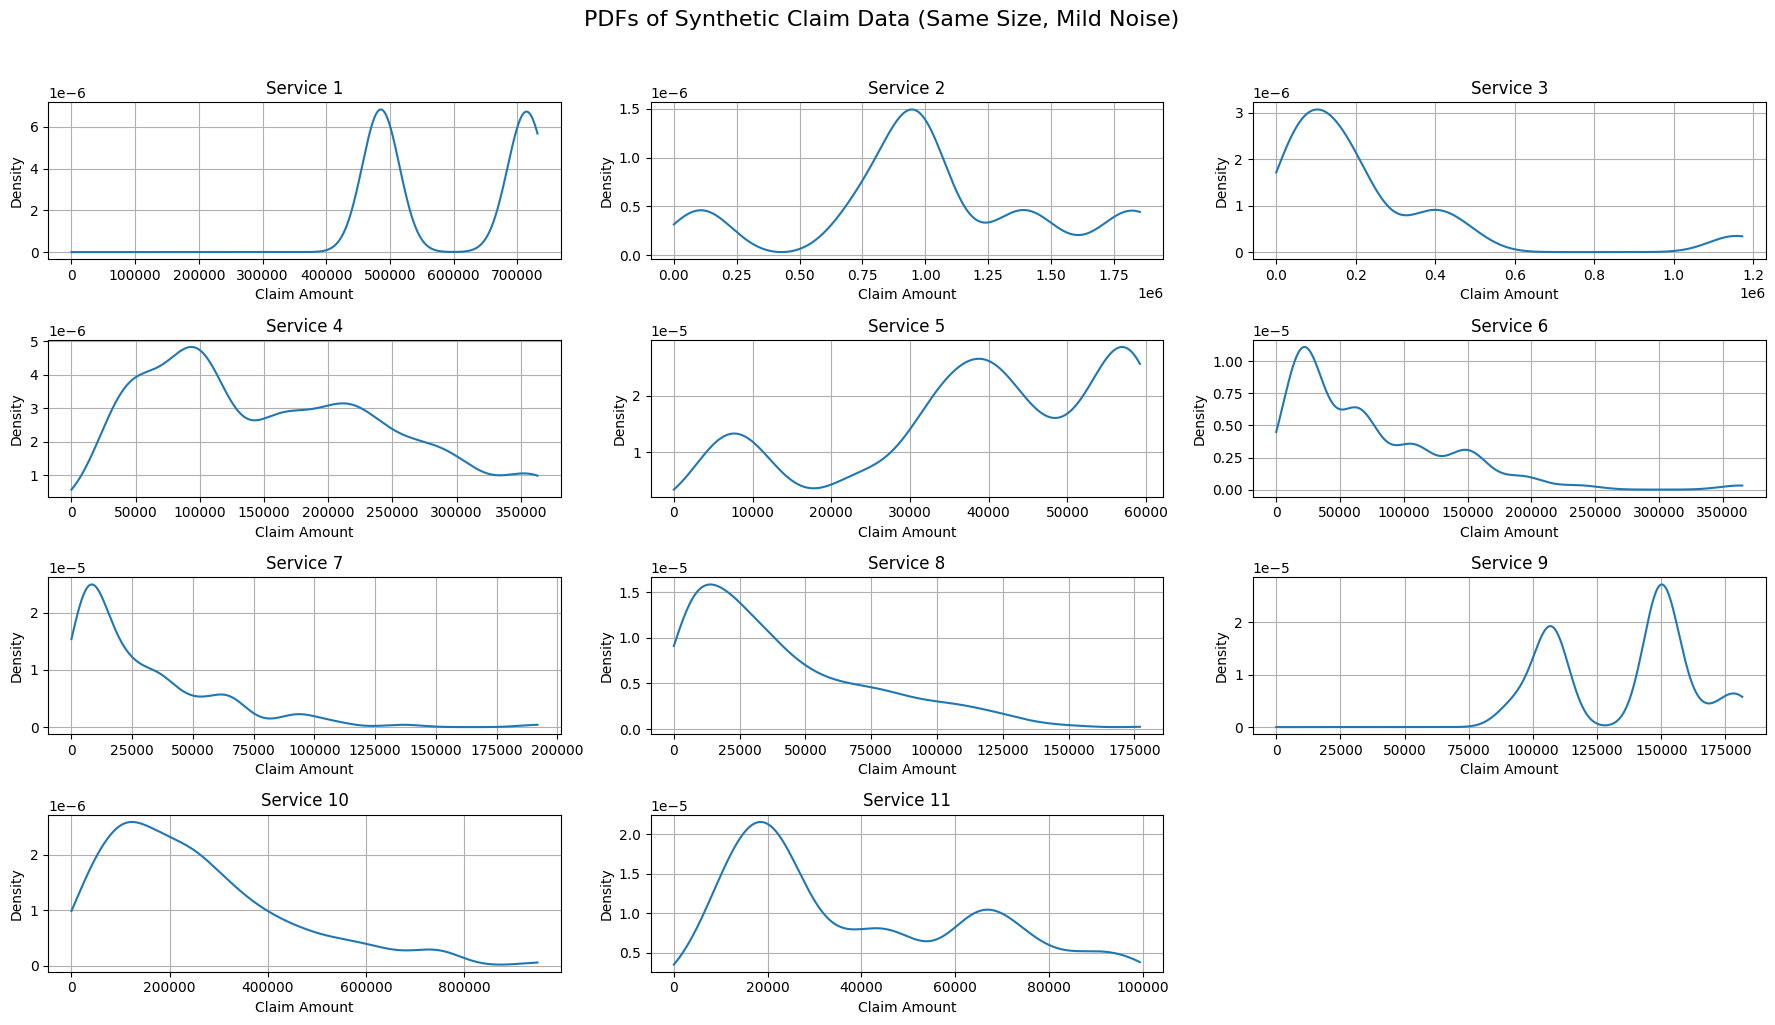

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gaussian_kde
import pickle

# === Load optimization_inputs ===
with open("optimization_inputs.pkl", "rb") as f:
    optimization_inputs = pickle.load(f)

n_services = len(optimization_inputs)
synthetic_data = []
np.random.seed(42)

# === Generate mildly jittered data of same size ===
for i, service in enumerate(optimization_inputs):
    c_ij = service["c_ij"]
    p_ij = service["p_ij"]
    samples = []

    total_samples = 1000  # or scale by actual length of c_ij × p_ij

    for c, p in zip(c_ij, p_ij):
        num_samples = max(1, int(round(p * total_samples)))
        bin_samples = np.random.normal(loc=c, scale=c * 0.01, size=num_samples)  # small noise
        bin_samples = np.clip(bin_samples, 0, None)  # avoid negative values
        samples.append(bin_samples)

    service_samples = np.concatenate(samples)
    synthetic_data.append(service_samples)

# === Plot PDFs ===
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i in range(n_services):
    data = synthetic_data[i]
    kde = gaussian_kde(data)
    x_vals = np.linspace(0, np.percentile(data, 99.5), 500)
    axes[i].plot(x_vals, kde(x_vals), label=f"Service {i+1}")
    axes[i].set_title(f"Service {i+1}")
    axes[i].set_xlabel("Claim Amount")
    axes[i].set_ylabel("Density")
    axes[i].grid(True)

# Turn off unused subplots
for j in range(n_services, len(axes)):
    axes[j].axis("off")

plt.suptitle("PDFs of Synthetic Claim Data (Same Size, Mild Noise)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()



In [2]:
import pandas as pd
import numpy as np
import os
import re

# === Directory with Excel files
data_dir = "services"  # adjust if needed

# === Optimized limits from improved solver (adaptive ε, weighted objective, λ=0.01)
selected_limits = [420000, 1436108, 630000, 210000, 31500, 313856, 103535, 98710, 105000, 483275, 58013]  # from improved solver (adaptive ε, weighted obj, λ=0.01)

# === Gather all service files
service_files = sorted(
    [f for f in os.listdir(data_dir) if f.startswith("services_") and f.endswith(".xlsx")],
    key=lambda f: int(re.search(r"services_(\d+)_", f).group(1))
)

results = []

for i, file in enumerate(service_files):
    # === Extract original limit from filename
    match = re.search(r"services_\d+_(\d+)\.xlsx", file)
    if not match:
        print(f"Skipping file {file} (invalid name)")
        continue
    original_limit = int(match.group(1))
    optimized_limit = selected_limits[i]

    # === Load claims
    df = pd.read_excel(os.path.join(data_dir, file))
    claims = df["ClaimedAmount"].dropna().values

    total_claimed = claims.sum()
    reimbursed_original = np.minimum(claims, original_limit).sum()
    reimbursed_optimized = np.minimum(claims, optimized_limit).sum()

    results.append({
        "Service": f"Service {i+1}",
        "Original Limit": original_limit,
        "Optimized Limit": optimized_limit,
        "Total Claimed": total_claimed,
        "Reimbursed (Original)": reimbursed_original,
        "Reimbursed (Optimized)": reimbursed_optimized,
        "Reduction": reimbursed_original - reimbursed_optimized,
        "Reduction (%)": 100 * (reimbursed_original - reimbursed_optimized) / reimbursed_original
    })

# === Create result DataFrame
df_results = pd.DataFrame(results)

# === Show
pd.set_option("display.float_format", "{:,.2f}".format)
display(df_results)

# === Totals
total_original = df_results["Reimbursed (Original)"].sum()
total_optimized = df_results["Reimbursed (Optimized)"].sum()
print("\n=== TOTALS ===")
print(f"Total Reimbursed (Original Limits): {total_original:,.2f}")
print(f"Total Reimbursed (Optimized Limits): {total_optimized:,.2f}")
print(f"Total Reduction: {(total_original - total_optimized):,.2f} ({100 * (total_original - total_optimized) / total_original:.2f}%)")


,Service,Original Limit,Optimized Limit,Total Claimed,Reimbursed (Original),Reimbursed (Optimized),Reduction,Reduction (%)
0,Service 1,400000,420000,"1,180,000.00","800,000.00","840,000.00","-40,000.00",-5.00
1,Service 2,1500000,1436108,"7,015,000.00","6,715,000.00","6,637,216.00","77,784.00",1.16
2,Service 3,600000,630000,"5,185,756.00","3,964,260.00","4,024,260.00","-60,000.00",-1.51
3,Service 4,200000,210000,"3,835,500.00","2,726,500.00","2,796,500.00","-70,000.00",-2.57
4,Service 5,30000,31500,"3,317,401.00","1,155,001.00","1,207,501.00","-52,500.00",-4.55
5,Service 6,300000,313856,"5,316,764.00","5,231,764.00","5,245,620.00","-13,856.00",-0.26
6,Service 7,100000,103535,"4,194,866.00","3,809,696.00","3,823,836.00","-14,140.00",-0.37
7,Service 8,100000,98710,"43,858,806.70","39,524,937.70","39,387,303.70","137,634.00",0.35
8,Service 9,100000,105000,"5,752,000.00","3,580,000.00","3,708,000.00","-128,000.00",-3.58
9,Service 10,500000,483275,"37,393,278.00","34,008,478.00","33,724,153.00","284,325.00",0.84



=== TOTALS ===
Total Reimbursed (Original Limits): 107,165,638.70
Total Reimbursed (Optimized Limits): 106,931,132.70
Total Reduction: 234,506.00 (0.22%)
